# ¿Puede una IA entender el mundo sin haberlo vivido?

66 modelos de lenguaje, entrenados solo con texto. El que más se parece a un cerebro humano **no es el más grande**.

**Paper:** [Revealing emergent human-like conceptual representations from language prediction](https://doi.org/10.1073/pnas.2512514122) · Xu et al., *PNAS*, 2025-10-31

**Video:** [Ver en YouTube Shorts](https://youtube.com/shorts/4ZfHcofzrLo)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2025-10-31-ia-conceptos-humanos-sin-vivir/notebook.ipynb)

## Lo que midieron

Xu et al. agarraron **66 modelos de lenguaje** — de 70 millones a 47 mil millones de parámetros — y les pidieron inferir conceptos a partir de pocos ejemplos dentro del prompt (*in-context learning*: aprender de lo que ves en la conversación, sin reentrenarte). Después comparamos la estructura interna de esas representaciones con cómo los humanos organizamos los mismos conceptos.

La pregunta es vieja: ¿se puede pensar como humano sin haber pateado una pelota, sentido miedo o probado una fruta? La respuesta que dan los datos es incómoda.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
MODELO_DESTACADO = 'llama3_8b'         # El más alineado con humanos (no el más grande)
MODELO_REFERENCIA = 'mistral0v1_8x7b'  # El más grande del corpus (47B params)
FUENTE = 'Fuente: Xu et al. (2025), PNAS | Datos: Zenodo 17092983'
COLOR_DATOS = '#2563EB'      # Azul CaM
COLOR_ALERTA = '#DC2626'     # Rojo — destacar outlier
COLOR_REFERENCIA = '#D97706' # Ámbar — baseline humano
COLOR_SECUNDARIO = '#059669' # Emerald — segundo dataset

# ══════════════════════════════════════════════════════════════
# Setup
# ══════════════════════════════════════════════════════════════
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2025-10-31-ia-conceptos-humanos-sin-vivir'

# Estilo CaM (local → fallback a GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve('https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle', style_file)
plt.style.use(style_file)

# ══════════════════════════════════════════════════════════════
# Descarga automática (si corre en Colab)
# ══════════════════════════════════════════════════════════════
os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)
for fn in ['modelos_alineacion.csv', 'convergencia_demos_llama3_70b.csv',
           'noise_ceiling_humano.csv', 'spose_dimensiones.csv', 'probing_escala.csv']:
    path = f'datos/{fn}'
    if not os.path.exists(path):
        urllib.request.urlretrieve(f'{BASE}/datos/{fn}', path)

# ══════════════════════════════════════════════════════════════
# Carga
# ══════════════════════════════════════════════════════════════
modelos = pd.read_csv('datos/modelos_alineacion.csv')
conv_llama = pd.read_csv('datos/convergencia_demos_llama3_70b.csv')
noise = pd.read_csv('datos/noise_ceiling_humano.csv')
spose = pd.read_csv('datos/spose_dimensiones.csv')

print(f'Modelos analizados: {len(modelos)} ({modelos["familia"].nunique()} familias)')
print(f'Tamaños: {modelos["params"].min()/1e6:.0f}M a {modelos["params"].max()/1e9:.1f}B parámetros (ratio {modelos["params"].max()/modelos["params"].min():.0f}x)')
print(f'Ejes semánticos humanos: {len(noise)} ({noise["dominio"].nunique()} dominios x {noise["atributo"].nunique()} atributos)')
print(f'Dimensiones SPoSE (THINGS): {len(spose)}')
print(f'Llama-3-70B, convergencia: {len(conv_llama)} puntos ({int(conv_llama["n_demostraciones"].min())} a {int(conv_llama["n_demostraciones"].max())} demostraciones)')

Modelos analizados: 66 (12 familias)
Tamaños: 70M a 46.7B parámetros (ratio 663x)
Ejes semánticos humanos: 52 (9 dominios x 17 atributos)
Dimensiones SPoSE (THINGS): 66
Llama-3-70B, convergencia: 8 puntos (1 a 96 demostraciones)


## Aquí está.

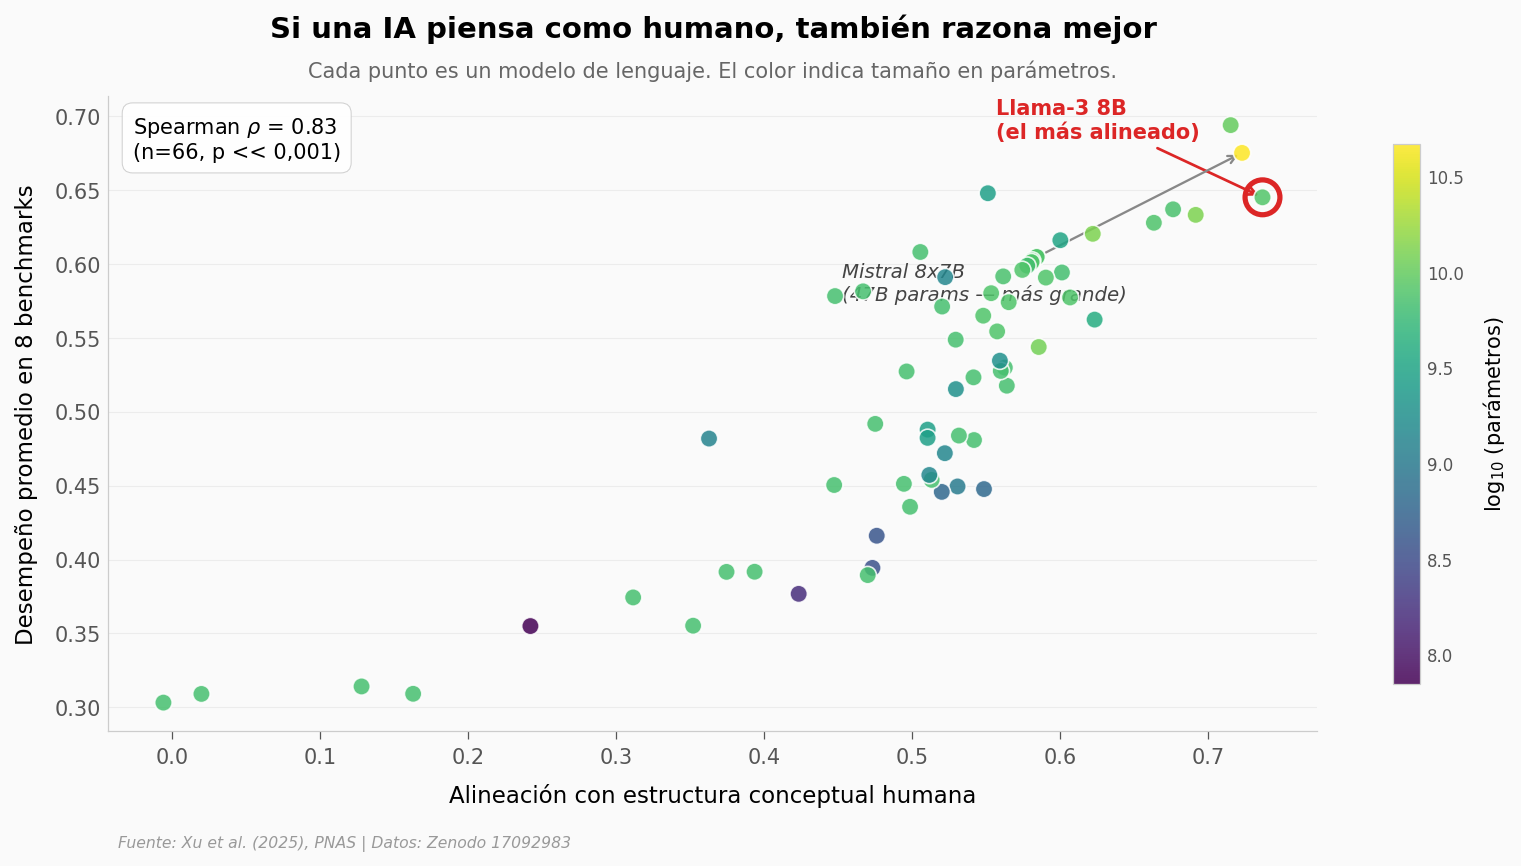

In [2]:
# Gráfica hero: alineación con humanos vs performance en benchmarks (n=66)
fig, ax = plt.subplots(figsize=(13, 5.5))

# Colormap por tamano (log de params) — cada modelo, un punto
log_params = np.log10(modelos['params'])
scatter = ax.scatter(modelos['alineacion'], modelos['perf_global'],
                     c=log_params, cmap='viridis', s=70, alpha=0.85,
                     edgecolors='white', linewidths=0.8, zorder=5)

# Destacar llama3_8b y mistral_8x7b
row_llama = modelos[modelos['modelo'] == MODELO_DESTACADO].iloc[0]
row_mistral = modelos[modelos['modelo'] == MODELO_REFERENCIA].iloc[0]
ax.scatter(row_llama['alineacion'], row_llama['perf_global'],
           s=280, facecolors='none', edgecolors=COLOR_ALERTA, linewidths=2.5, zorder=6)
ax.annotate(f'Llama-3 8B\n(el más alineado)',
            xy=(row_llama['alineacion'], row_llama['perf_global']),
            xytext=(row_llama['alineacion']-0.18, row_llama['perf_global']+0.04),
            fontsize=10, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.3))
ax.annotate(f'Mistral 8x7B\n(47B params — más grande)',
            xy=(row_mistral['alineacion'], row_mistral['perf_global']),
            xytext=(row_mistral['alineacion']-0.27, row_mistral['perf_global']-0.10),
            fontsize=9.5, color='#444444', style='italic',
            arrowprops=dict(arrowstyle='->', color='#888888', lw=1.1))

# Spearman (no-normal por construccion)
rho, p = stats.spearmanr(modelos['alineacion'], modelos['perf_global'])
ax.text(0.02, 0.97, f'Spearman $\\rho$ = {rho:.2f}\n(n=66, p << 0,001)',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#CCCCCC', alpha=0.9))

cbar = plt.colorbar(scatter, ax=ax, shrink=0.85)
cbar.set_label('log$_{10}$ (parámetros)', fontsize=10)
cbar.ax.tick_params(labelsize=8)

ax.set_xlabel('Alineación con estructura conceptual humana', fontsize=11)
ax.set_ylabel('Desempeño promedio en 8 benchmarks', fontsize=11)
ax.set_title('Si una IA piensa como humano, también razona mejor',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto es un modelo de lenguaje. El color indica tamaño en parámetros.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_alineacion_vs_performance.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos nos dicen

- **La correlación es fuerte** ($\rho=0{,}83$, n=66): un modelo más alineado con humanos tiende a razonar mejor en tareas generales. La estructura conceptual predice el desempeño.
- **El ganador no es el gigante.** El modelo más alineado con humanos ($0{,}74$) es Llama-3 **8B**, no Mistral **47B**. El 663× de diferencia en parámetros no se traduce en 663× de ventaja conceptual.
- **Hay modelos que fallan en alinearse pese al tamaño.** Modelos de la familia Pythia a escalas medianas se quedan atrás — el entrenamiento y la arquitectura importan tanto como la escala.

Esto es Spearman sobre rangos, no regresión lineal — no digas "$\rho^2$ explica el $70\%$ de la varianza". Es concordancia de rankings, no varianza explicada.

## Zoom: ¿cómo aparece esa estructura?

Una pregunta distinta: **¿cómo de rápido emerge la estructura conceptual dentro de un solo modelo** a medida que recibe más ejemplos (*demostraciones in-context*)?

Xu et al. le dieron a Llama-3-70B entre 1 y 96 ejemplos de cada concepto y midieron dos cosas en paralelo: qué tan estable era su representación interna y qué tan bien acertaba en la tarea.

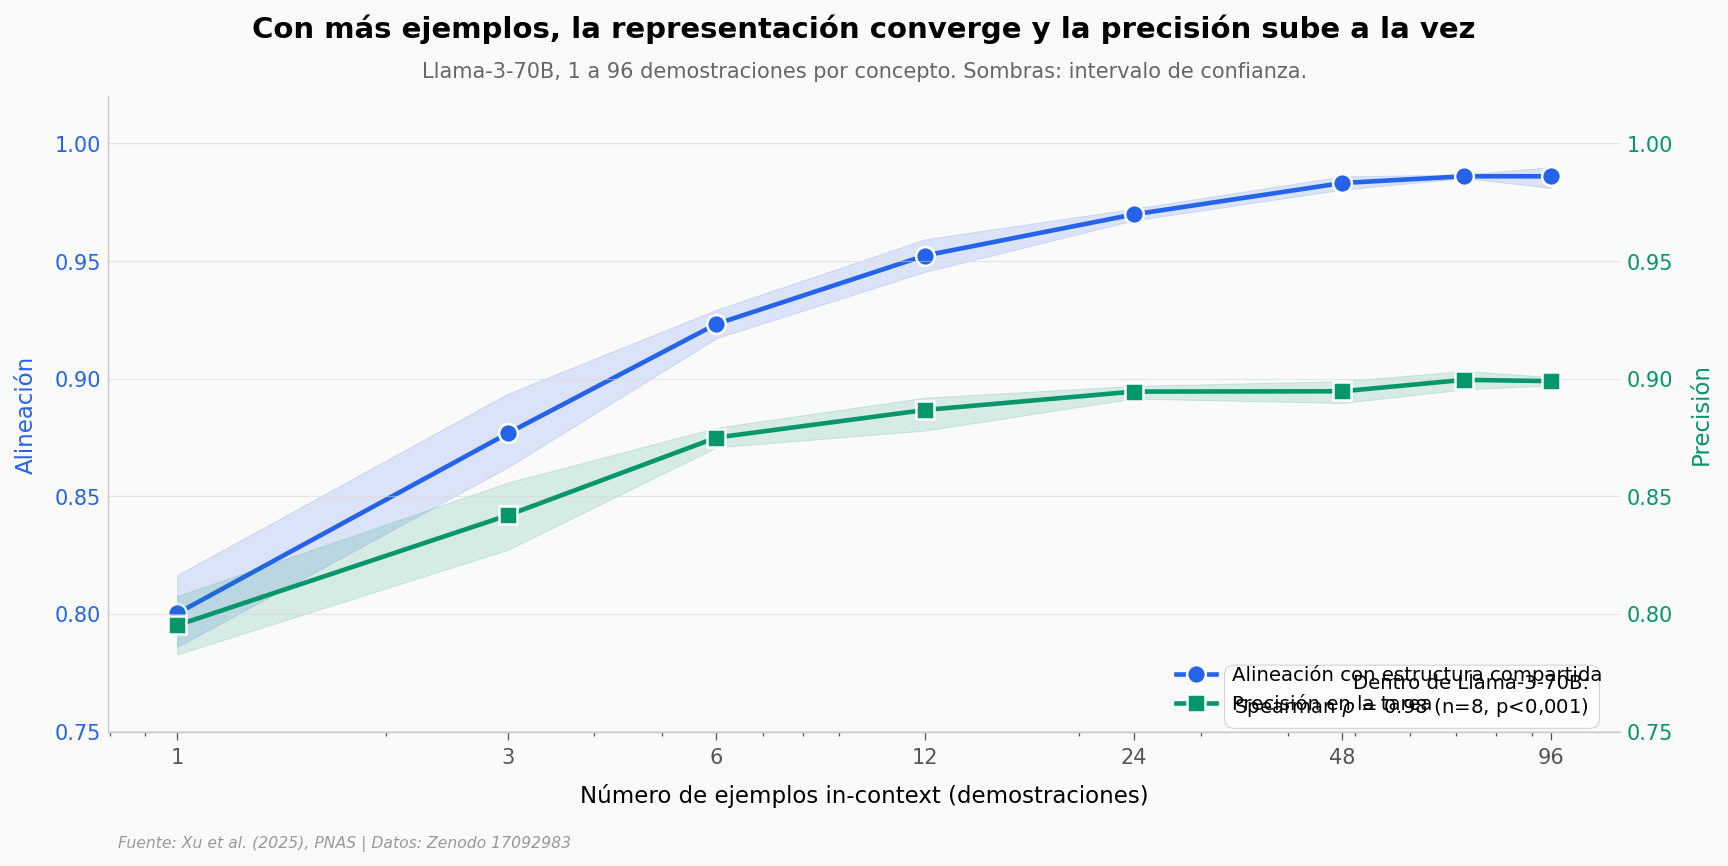

In [3]:
# Convergencia in-context (llama3-70b): dentro del mismo modelo, n=8 puntos
fig, ax1 = plt.subplots(figsize=(13, 5.5))

# Eje izquierdo: alineacion
line1 = ax1.plot(conv_llama['n_demostraciones'], conv_llama['alineacion'],
                 marker='o', markersize=9, linewidth=2.2, color=COLOR_DATOS,
                 markerfacecolor=COLOR_DATOS, markeredgecolor='white',
                 markeredgewidth=1.2, label='Alineación con estructura compartida')
ax1.fill_between(conv_llama['n_demostraciones'],
                 conv_llama['alineacion_lo'], conv_llama['alineacion_hi'],
                 color=COLOR_DATOS, alpha=0.15)
ax1.set_xlabel('Número de ejemplos in-context (demostraciones)', fontsize=11)
ax1.set_ylabel('Alineación', fontsize=11, color=COLOR_DATOS)
ax1.tick_params(axis='y', labelcolor=COLOR_DATOS)
ax1.set_xscale('log')
ax1.set_xticks([1, 3, 6, 12, 24, 48, 96])
ax1.set_xticklabels(['1', '3', '6', '12', '24', '48', '96'])
ax1.set_ylim(0.75, 1.02)

# Eje derecho: accuracy
ax2 = ax1.twinx()
line2 = ax2.plot(conv_llama['n_demostraciones'], conv_llama['accuracy'],
                 marker='s', markersize=9, linewidth=2.2, color=COLOR_SECUNDARIO,
                 markerfacecolor=COLOR_SECUNDARIO, markeredgecolor='white',
                 markeredgewidth=1.2, label='Precisión en la tarea')
ax2.fill_between(conv_llama['n_demostraciones'],
                 conv_llama['accuracy_lo'], conv_llama['accuracy_hi'],
                 color=COLOR_SECUNDARIO, alpha=0.15)
ax2.set_ylabel('Precisión', fontsize=11, color=COLOR_SECUNDARIO)
ax2.tick_params(axis='y', labelcolor=COLOR_SECUNDARIO)
ax2.set_ylim(0.75, 1.02)

# Spearman within-model (n=8)
rho, p = stats.spearmanr(conv_llama['alineacion'], conv_llama['accuracy'])
ax1.text(0.98, 0.03, f'Dentro de Llama-3-70B:\nSpearman $\\rho$ = {rho:.2f} (n=8, p<0,001)',
         transform=ax1.transAxes, fontsize=9.5, ha='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#CCCCCC', alpha=0.9))

ax1.set_title('Con más ejemplos, la representación converge y la precisión sube a la vez',
              fontsize=14, fontweight='bold', pad=28)
ax1.text(0.5, 1.03, 'Llama-3-70B, 1 a 96 demostraciones por concepto. Sombras: intervalo de confianza.',
         transform=ax1.transAxes, fontsize=10, color='#666666', ha='center')

# Leyenda combinada
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, fontsize=9.5, loc='lower right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/convergencia_llama3_70b.png', dpi=200, bbox_inches='tight')
plt.show()

## El baseline humano

Antes de celebrar que una IA se parece a un humano, hay que preguntar: **¿qué tan de acuerdo están los humanos entre sí?** Si los juicios humanos son ruidosos, alinearse con ellos significa poco.

Xu et al. miden el *noise ceiling* (literal: techo de ruido) de cada eje semántico: dividen a los participantes humanos en dos mitades y miden cuánto coinciden entre sí. Eso marca el límite superior — ninguna IA puede alinearse con humanos mejor de lo que los humanos se alinean entre ellos. Si el valor es 1, acuerdo perfecto. Si es 0, ruido puro.

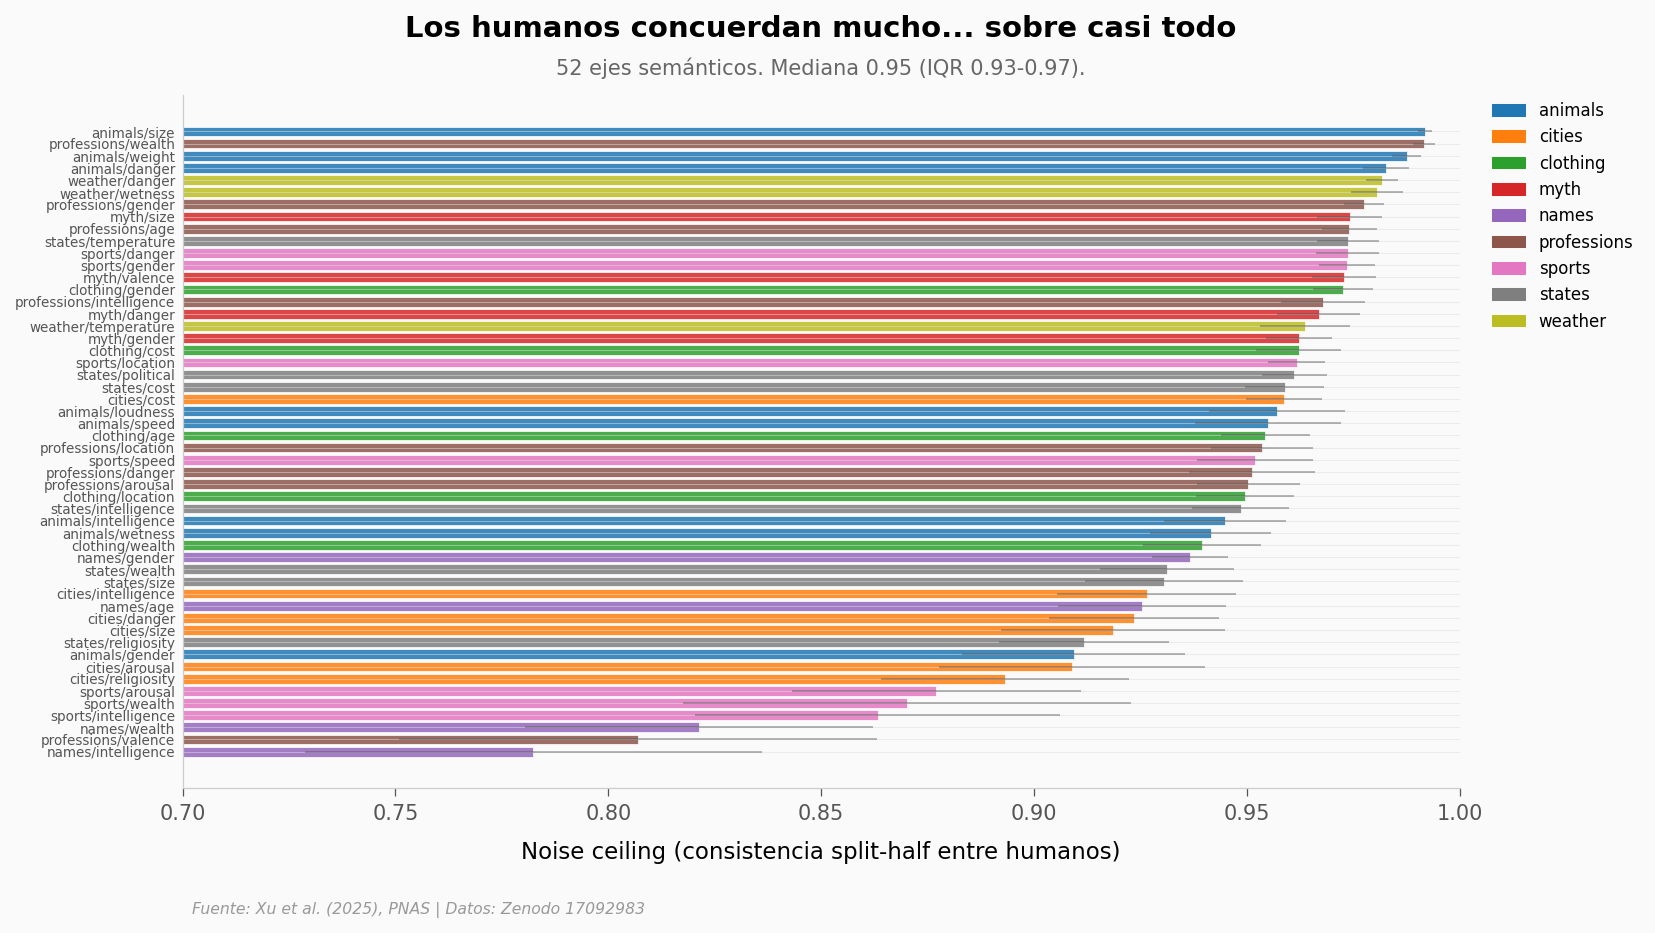


Mas reproducible: animals/size = 0.992
Menos reproducible: names/intelligence = 0.782


In [4]:
# Noise ceiling humano: 52 ejes semanticos (9 dominios x 17 atributos)
fig, ax = plt.subplots(figsize=(13, 6))

# Un color por dominio
dominios = sorted(noise['dominio'].unique())
cmap = plt.cm.tab10
colors = {d: cmap(i / len(dominios)) for i, d in enumerate(dominios)}

# Ordenar por noise_ceiling descendente
noise_sorted = noise.sort_values('noise_ceiling', ascending=False).reset_index(drop=True)

for i, row in noise_sorted.iterrows():
    ax.barh(i, row['noise_ceiling'], color=colors[row['dominio']],
            alpha=0.85, edgecolor='white', linewidth=0.4)
    # Error bar
    ax.errorbar(row['noise_ceiling'], i, xerr=row['noise_ceiling_se'],
                fmt='none', ecolor='#555555', capsize=0, linewidth=0.8, alpha=0.5)

# Labels de eje: combinar dominio + atributo
labels = [f"{r['dominio']}/{r['atributo']}" for _, r in noise_sorted.iterrows()]
ax.set_yticks(range(len(noise_sorted)))
ax.set_yticklabels(labels, fontsize=6.5)
ax.invert_yaxis()
ax.set_xlim(0.7, 1.0)
ax.set_xlabel('Noise ceiling (consistencia split-half entre humanos)', fontsize=11)
ax.set_title('Los humanos concuerdan mucho... sobre casi todo',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'52 ejes semánticos. Mediana {noise["noise_ceiling"].median():.2f} (IQR {noise["noise_ceiling"].quantile(0.25):.2f}-{noise["noise_ceiling"].quantile(0.75):.2f}).',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Leyenda externa por dominio
from matplotlib.patches import Patch
legend_patches = [Patch(color=colors[d], label=d) for d in dominios]
ax.legend(handles=legend_patches, fontsize=8, loc='upper left',
          bbox_to_anchor=(1.02, 1.0), borderaxespad=0, framealpha=0.9, ncol=1)
plt.subplots_adjust(right=0.78)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/noise_ceiling_humano.png', dpi=200, bbox_inches='tight')
plt.show()

# Extremos
print(f'\nMas reproducible: {noise_sorted.iloc[0]["dominio"]}/{noise_sorted.iloc[0]["atributo"]} = {noise_sorted.iloc[0]["noise_ceiling"]:.3f}')
print(f'Menos reproducible: {noise_sorted.iloc[-1]["dominio"]}/{noise_sorted.iloc[-1]["atributo"]} = {noise_sorted.iloc[-1]["noise_ceiling"]:.3f}')

## ¿Qué tan raro es Llama-3 8B?

Si miramos la distribución de alineación con humanos entre los 66 modelos, ¿dónde cae exactamente el ganador?

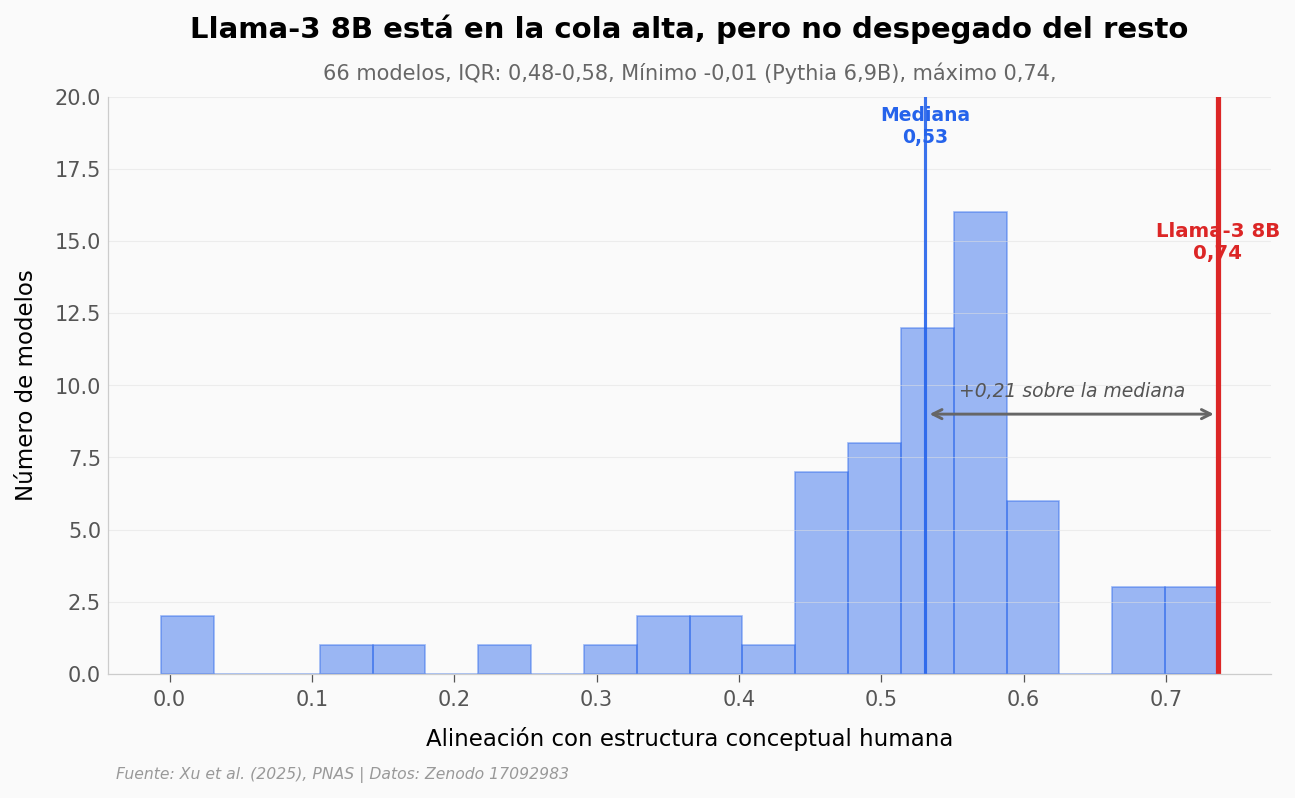

In [5]:
# Histograma de anomalia: distribucion de alineacion en 66 modelos
fig, ax = plt.subplots(figsize=(10, 5))

alineacion = modelos['alineacion']
mediana = alineacion.median()
media = alineacion.mean()
iqr_lo = alineacion.quantile(0.25)
iqr_hi = alineacion.quantile(0.75)

n, bins, patches = ax.hist(alineacion, bins=20, color=COLOR_DATOS, alpha=0.45,
                           edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.25
ax.set_ylim(0, y_max)

# Linea mediana
ax.axvline(x=mediana, color=COLOR_DATOS, linewidth=1.5, linestyle='-', alpha=0.9)
ax.text(mediana, y_max*0.92, f'Mediana\n{mediana:.2f}'.replace('.', ','),
        ha='center', fontsize=9, color=COLOR_DATOS, fontweight='bold')

# Linea llama3_8b
llama_al = modelos[modelos['modelo'] == MODELO_DESTACADO]['alineacion'].values[0]
ax.axvline(x=llama_al, color=COLOR_ALERTA, linewidth=2.5)
ax.text(llama_al, y_max*0.72, f'Llama-3 8B\n{llama_al:.2f}'.replace('.', ','),
        ha='center', fontsize=9.5, color=COLOR_ALERTA, fontweight='bold')

# Flecha entre mediana y llama3_8b
ax.annotate('', xy=(llama_al, y_max*0.45), xytext=(mediana, y_max*0.45),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.4))
ax.text((mediana+llama_al)/2, y_max*0.48,
        f'+{(llama_al-mediana):.2f} sobre la mediana'.replace('.', ','),
        ha='center', fontsize=9, color='#555555', style='italic')

ax.set_xlabel('Alineación con estructura conceptual humana', fontsize=11)
ax.set_ylabel('Número de modelos', fontsize=11)
ax.set_title('Llama-3 8B está en la cola alta, pero no despegado del resto',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'66 modelos. IQR: {iqr_lo:.2f}-{iqr_hi:.2f}. Mínimo {alineacion.min():.2f} (Pythia 6.9B), máximo {alineacion.max():.2f}.'.replace('.', ','),
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_alineacion.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|:---:|---------|
| Alineación con humanos predice desempeño | ✅ | $\rho=0{,}83$ (Spearman, n=66 modelos, p<<0{,}001). Cross-models. |
| Dentro de un modelo, alinear ≈ acertar | ✅ | $\rho=0{,}98$ (Spearman, n=8 puntos de Llama-3-70B con 1 a 96 demos, p<0{,}001). Within-model, distinto del cross-models. |
| El tamaño del modelo no lo explica todo | ✅ | $\rho=0{,}49$ entre tamaño y alineación. El modelo más alineado (Llama-3 **8B**, $0{,}74$) no es el más grande (Mistral 47B, $0{,}72$). |
| Los humanos concuerdan mucho al juzgar conceptos | ✅ | Mediana del *noise ceiling* = $0{,}95$ sobre 52 ejes (IQR $0{,}93$–$0{,}97$). |
| Las LLM tienen representaciones "biológicamente plausibles" | ⚠️ | El paper lo enmarca como "aportan evidencia consistente con" patrones neuronales (fMRI). Ese componente neural no está en este notebook — hace falta descargar los datos de imagen cerebral. |

> **Limitaciones:** (1) Es un estudio **computacional comparativo**, no un experimento causal — los modelos no se "manipularon", se compararon tal como vienen entrenados. Podemos decir *emerge una estructura que coincide con la humana*, no *el entrenamiento causa estructura humana*. (2) La correlación cross-models ($n=66$) y within-model ($n=8$) viven en ejes distintos — no comparar magnitudes directamente. (3) El paper reclama tres cosas: convergencia, predicción de desempeño y similitud con cerebro humano. Este notebook reproduce las dos primeras; la tercera requiere datos fMRI que no descargamos. (4) Spearman opera sobre rangos: reportar $\rho^2$ como "varianza explicada" sería un abuso de lenguaje — esa interpretación es exclusiva de Pearson sobre datos lineales y normales.

## Ahora tú

Tres preguntas que los datos pueden responder:

1. **¿Qué familia de modelos (Llama, Pythia, Mistral...) tiene la mejor alineación mediana?** Pista: `modelos.groupby('familia')['alineacion'].median().sort_values(ascending=False)`
2. **¿Con cuántos ejemplos *in-context* alcanza Llama-3-70B el 95% de su alineación final?** Pista: cruzar `conv_llama['alineacion']` con un umbral.
3. **¿Cuál es el eje semántico con menor acuerdo humano, y por qué tiene sentido?** Pista: `noise.nsmallest(5, 'noise_ceiling')`.

In [6]:
# --- EXPERIMENTA AQUI ---
# Respuesta a la pregunta 1: mejor familia por mediana de alineacion.
ranking = (modelos.groupby('familia')
           .agg(mediana_alineacion=('alineacion', 'median'),
                n_modelos=('alineacion', 'size'))
           .sort_values('mediana_alineacion', ascending=False))
print('Mediana de alineación por familia (n = número de modelos en el corpus):\n')
print(ranking.to_string(float_format=lambda x: f'{x:.3f}'))

print('\n--- Prueba cambiando: ---')
print('ranking_por_tamaño = modelos.groupby("familia")["params"].median().sort_values()')
print('Pregunta: ¿la familia más pequeña es la más alineada, o no hay relación limpia?')

Mediana de alineación por familia (n = número de modelos en el corpus):

         mediana_alineacion  n_modelos
familia                               
llama3                0.737          1
mistral               0.699          2
gemma                 0.658          2
llama2                0.635          2
llama                 0.612          2
neo                   0.577         10
falcon                0.561          1
qwen                  0.559          7
phi                   0.537          2
opt                   0.511          4
pythia                0.499         21
olmo                  0.457         12

--- Prueba cambiando: ---
ranking_por_tamaño = modelos.groupby("familia")["params"].median().sort_values()
Pregunta: ¿la familia más pequeña es la más alineada, o no hay relación limpia?


## Fuentes

**Paper**: [Revealing emergent human-like conceptual representations from language prediction](https://doi.org/10.1073/pnas.2512514122)  
*Proceedings of the National Academy of Sciences, 2025-10-31*

**Datos**: [Code and Data — Revealing emergent human-like conceptual representations from language prediction](https://doi.org/10.5281/zenodo.17092983)  
*Zenodo, 2025-09-10*

*14 afirmaciones verificadas contra estas fuentes*

---

**Canal:** [Ciencia a Mordiscos](https://cienciaamordiscos.com) · [YouTube](https://youtube.com/@cienciaamordiscos) · [GitHub (repo Lab)](https://github.com/Ciencia-a-Mordiscos/lab)
**Licencia:** Notebook y código, MIT. Datos, según el repositorio de origen.